# Data Exploration

Initial exploration of simulation data using the `reconn_wave_power` module.

In [6]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

from reconn_wave_power.io import read_simulation
from reconn_wave_power.spectrum import compute_psd_time, compute_psd_space, compute_komega_2d
from reconn_wave_power.plotting import plot_psd

%matplotlib inline

## Configuration

Set paths to your simulation data here.

In [2]:
# Path to simulation input file and output folder
INPUT_FILE = "/Users/colby/Research/Projects/My_Projects/2026.Reconn_Wave_Power/test_sim_data/test00/input/input"
OUTPUT_FOLDER = "/Users/colby/Research/Projects/My_Projects/2026.Reconn_Wave_Power/test_sim_data/test00/Output"

## Load Simulation Data

In [3]:
# Load E and B fields for all timesteps
ds = read_simulation(
    input_file=INPUT_FILE,
    output_folder=OUTPUT_FOLDER,
    fields=("E", "B"),
    progress=True,
)
ds

/Users/colby/mambaforge/envs/reconn-wave-power/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading timesteps: 100%|██████████| 1001/1001 [00:44<00:00, 22.29ts/s]


<xarray.Dataset> Size: 15GB
Dimensions:  (time: 1001, x: 1600, y: 400)
Coordinates:
  * time     (time) float64 8kB 0.05 2.0 4.0 6.0 ... 1.996e+03 1.998e+03 2e+03
  * x        (x) float64 13kB 0.25 0.75 1.25 1.75 ... 798.2 798.8 799.2 799.8
  * y        (y) float64 3kB 0.25 0.75 1.25 1.75 ... 198.2 198.8 199.2 199.8
Data variables:
    Ex       (time, x, y) float32 3GB dask.array<chunksize=(1, 1600, 400), meta=np.ndarray>
    Ey       (time, x, y) float32 3GB dask.array<chunksize=(1, 1600, 400), meta=np.ndarray>
    Ez       (time, x, y) float32 3GB dask.array<chunksize=(1, 1600, 400), meta=np.ndarray>
    Bx       (time, x, y) float32 3GB dask.array<chunksize=(1, 1600, 400), meta=np.ndarray>
    By       (time, x, y) float32 3GB dask.array<chunksize=(1, 1600, 400), meta=np.ndarray>
    Bz       (time, x, y) float32 3GB dask.array<chunksize=(1, 1600, 400), meta=np.ndarray>
Attributes:
    dt:       0.05

In [8]:
# Check what we loaded
print("Variables:", list(ds.data_vars))
print("Dimensions:", dict(ds.sizes))
print("Attributes:", ds.attrs)

Variables: ['Ex', 'Ey', 'Ez', 'Bx', 'By', 'Bz']
Dimensions: {'time': 1001, 'x': 1600, 'y': 400}
Attributes: {'dt': 0.05}


## Quick Look at the Data

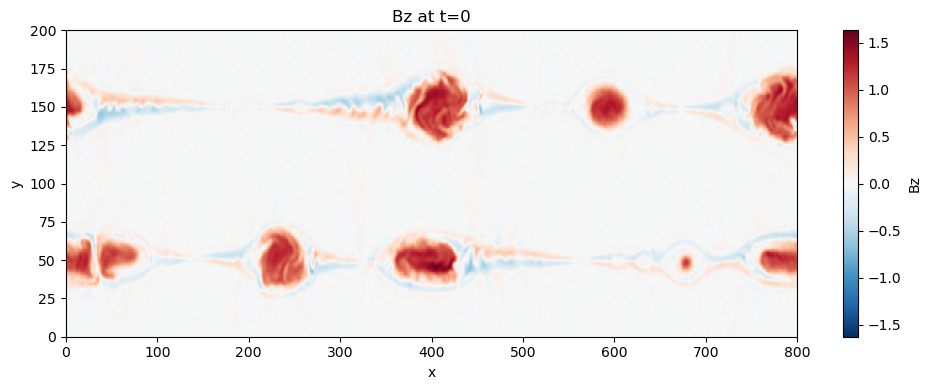

In [17]:
# Plot a single component at a single timestep
fig, ax = plt.subplots(figsize=(10, 4))
ds["Bz"].isel(time=200).plot(ax=ax, x="x", y="y")
plt.title("Bz at t=0")
plt.tight_layout()

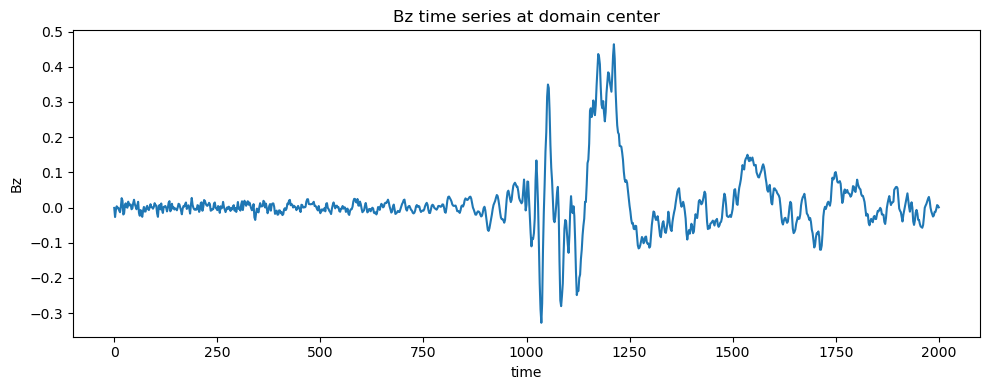

In [18]:
# Time series at a specific location
# Adjust x, y indices based on your data dimensions
fig, ax = plt.subplots(figsize=(10, 4))
ds["Bz"].isel(x=ds.sizes["x"]//2, y=ds.sizes["y"]//2).plot(ax=ax)
plt.title("Bz time series at domain center")
plt.tight_layout()

## Time-Domain Power Spectrum

In [7]:
# Extract a time series at a single spatial point
bz_ts = ds["Bz"].isel(x=ds.sizes["x"]//2, y=ds.sizes["y"]//2)
dt = ds.attrs.get("dt", 1.0)  # fallback to 1.0 if not set

print(f"Time series length: {len(bz_ts.time)} points")
print(f"dt = {dt}")

Time series length: 1001 points
dt = 0.05


In [ ]:
# Compute PSD
f, Pxx = compute_psd_time(bz_ts, dt=dt)

fig, ax = plt.subplots(figsize=(8, 5))
plot_psd(f, Pxx, label="Bz", ax=ax)
plt.title("Bz Power Spectrum (time domain)")
plt.tight_layout()

## Spatial Power Spectrum

In [ ]:
# Compute spatial PSD along x at a single timestep
bz_spatial = ds["Bz"].isel(time=0, y=ds.sizes["y"]//2)
dx = ds.attrs.get("dx", 1.0)

k, Pk = compute_psd_space(bz_spatial, dx=dx, axis="x")

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(k, Pk)
ax.set_xlabel("Wavenumber k [rad/m]")
ax.set_ylabel("Power")
ax.set_title("Bz Spatial Power Spectrum")
plt.tight_layout()

## k-omega Spectrum (2D)

In [ ]:
# Extract a 2D slice (x, time) at fixed y
bz_xt = ds["Bz"].isel(y=ds.sizes["y"]//2).values  # shape: (time, x)

# compute_komega_2d expects (space, time) or specify axes
# Our data is (time, x), so axes=(1, 0) means space=axis1, time=axis0
k, omega, P = compute_komega_2d(bz_xt, dx=dx, dt=dt, axes=(1, 0))

print(f"k range: {k.min():.3f} to {k.max():.3f} rad/m")
print(f"omega range: {omega.min():.3f} to {omega.max():.3f} rad/s")

In [ ]:
# Plot k-omega spectrum
fig, ax = plt.subplots(figsize=(10, 6))
im = ax.pcolormesh(k, omega, P.T, shading="auto", cmap="inferno", 
                   norm=plt.matplotlib.colors.LogNorm())
plt.colorbar(im, ax=ax, label="Power")
ax.set_xlabel("Wavenumber k [rad/m]")
ax.set_ylabel("Frequency omega [rad/s]")
ax.set_title("k-omega Spectrum")
plt.tight_layout()

## Scratch Space

Use cells below for quick tests and exploration.